In [3]:
import tensorflow as tf

In [4]:
# kerasın hazır datasetlerinden olan mnistin bir verisyonunu kullanıyoruz
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()

In [5]:
# test ve eğitim verilerini ayırıyoruz
(X_train_full,y_train_full), (X_test,y_test) = fashion_mnist

In [6]:
# eğitim için son 5000 değeri alıyoruz train için ise ilk 5000 değeri alıyoruz X trainin tamamından
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

In [7]:
import numpy as np

print("Train images:", X_train.shape)
print("Train labels:", np.unique(y_train))
print("Test images:", X_test.shape)
print("Test labels:", np.unique(y_test))

Train images: (55000, 28, 28)
Train labels: [0 1 2 3 4 5 6 7 8 9]
Test images: (10000, 28, 28)
Test labels: [0 1 2 3 4 5 6 7 8 9]


In [8]:
X_train.dtype

dtype('uint8')

In [9]:
# ölçeklendirmek için bölüyoruz
X_train , X_valid, X_test = X_train/255.0, X_valid/255.0, X_test/255.0

In [10]:
# bunlar da hedef classlarımız
class_names = ["T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

In [11]:
class_names[y_train[0]]

'Ankle boot'

In [12]:
# modelin  layerlarını ayarlıyoruz
tf.random.set_seed(42)
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=[28,28]))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(300, activation="relu"))
model.add(tf.keras.layers.Dense(100, activation="relu"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.layers

[<Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>,
 <Dense name=dense_2, built=True>]

In [15]:
hidden1 = model.layers[1]
hidden1.name

'dense'

In [16]:
weights , biases = hidden1.get_weights()

In [17]:
weights

array([[-0.05720295,  0.07205902, -0.06828599, ...,  0.05533949,
        -0.06249873,  0.05370061],
       [ 0.05077405, -0.05898438, -0.0400942 , ..., -0.00978358,
         0.03535048, -0.07350148],
       [ 0.00762144, -0.06230786, -0.026935  , ...,  0.04368236,
         0.05196221, -0.0126745 ],
       ...,
       [-0.03639893, -0.03786431, -0.02084932, ...,  0.01011828,
        -0.03227491,  0.06577387],
       [-0.02735397,  0.01094206, -0.04749844, ..., -0.07082141,
        -0.06844493, -0.02307899],
       [-0.03767634, -0.06051707,  0.00670113, ...,  0.0587699 ,
         0.01924344, -0.04625253]], shape=(784, 300), dtype=float32)

In [18]:
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [19]:
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="sgd",
    metrics=["accuracy"]
)

In [20]:
history = model.fit(X_train, y_train, epochs=100, validation_data=(X_valid, y_valid))

Epoch 1/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 684us/step - accuracy: 0.7698 - loss: 0.7129 - val_accuracy: 0.8316 - val_loss: 0.4960
Epoch 2/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 618us/step - accuracy: 0.8339 - loss: 0.4824 - val_accuracy: 0.8412 - val_loss: 0.4468
Epoch 3/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 634us/step - accuracy: 0.8477 - loss: 0.4388 - val_accuracy: 0.8502 - val_loss: 0.4263
Epoch 4/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 675us/step - accuracy: 0.8559 - loss: 0.4126 - val_accuracy: 0.8520 - val_loss: 0.4121
Epoch 5/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 665us/step - accuracy: 0.8624 - loss: 0.3929 - val_accuracy: 0.8558 - val_loss: 0.4008
Epoch 6/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 665us/step - accuracy: 0.8672 - loss: 0.3770 - val_accuracy: 0.8592 - val_loss: 0.3924
Epoch 7/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 652us/step - accuracy: 0.8711 - loss: 0.3637 - val_accuracy: 0.8616 - val_loss: 0.3850
Epoch 8/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 1s 717us/step - accuracy: 

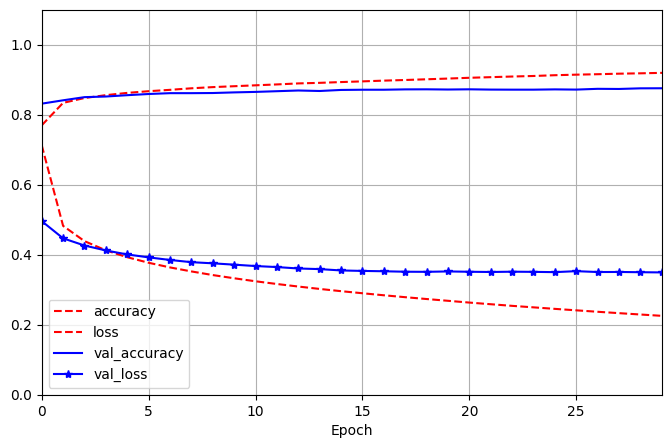

In [21]:
# accruracy ve loss değişimlerini gösteriyoruz
import matplotlib.pyplot as plt
import pandas as pd

pd.DataFrame(history.history).plot(figsize=(8,5),
                                   xlim=(0,29),
                                   ylim=(0,1.1),
                                   grid=True,
                                   xlabel="Epoch",
                                   style = ["r--","r--","b-","b-*"])
plt.show()

In [22]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 688us/step - accuracy: 0.8802 - loss: 0.5033


[0.5032646656036377, 0.8802000284194946]

In [23]:
X_new = X_test[:3]
y_proba = model.predict(X_new)
y_proba.round(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [24]:
y_pred = np.argmax(y_proba, axis=-1)
y_pred

array([9, 2, 1])

In [25]:
np.array(class_names)[y_pred]

array(['Ankle boot', 'Pullover', 'Trouser'], dtype='<U11')

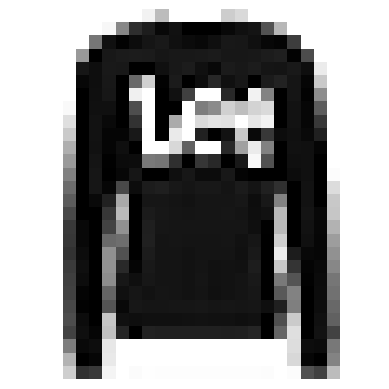

Predicted class: Pullover


In [26]:
import matplotlib.pyplot as plt

plt.imshow(X_test[1], cmap="binary")
plt.axis("off")
plt.show()
print(f"Predicted class: {class_names[y_pred[1]]}")